In [1]:
import importlib
import smw_setup
importlib.reload(smw_setup)
from smw_setup import *


#### PPO Algorithm

In [9]:
try:
    base_env.close()
except:
    pass

In [7]:
base_env = stable_retro.make('SuperMarioWorld-Snes-v0', render_mode='human')
# base_env = stable_retro.make('SuperMarioWorld-Snes-v0', render_mode='none')
env = SMWEnv(base_env)

total_rewards = []
steps_per_ep  = []
max_x_per_ep  = []
actor_losses  = []
critic_losses = []

In [4]:
class SMW_PPO:
    def __init__(self, env, obs_dim, action_dim, theta, epsilon = 0.2, alpha = 0.95, gamma=0.99, num_steps=4096):
        self.env = env
        self.gamma = gamma
        self.alpha = alpha
        self.epsilon = epsilon
        self.num_steps = num_steps
        self.num_eps = 10

        #create array for collecting trajectories
        self.states    = []
        self.actions   = []
        self.rewards   = []
        self.log_probs = []
        self.values    = []
        self.dones     = []
        self.theta = theta

        self.state, _ = self.env.reset()

        #call in my actor and critic class and optimize them
        self.actor = Actor(obs_dim=9, action_dim=self.env.action_space.n)
        self.critic = Critic(obs_dim=9)
        self.actor_optimizer  = optim.Adam(self.actor.parameters(),  lr=1e-4)
        self.critic_optimizer = optim.Adam(self.critic.parameters(), lr=1e-3)

        self.policy = []
        
    def collect_trajectories(self):
        #iterate through my steps typically PPO is 2048
        # for _ in range(self.num_steps):
        done = False
        while not done:
            #set up my actor and critic
            action, log_prob, _ = self.actor(torch.tensor(self.state, dtype=torch.float32))
            action_idx = action.item()
            # print(action_idx)
            next_state, reward, terminated, truncated, info = self.env.step(action_idx)
            done = terminated or truncated
            value = self.critic(torch.tensor(self.state, dtype=torch.float32))


            #grab all my trajectories and append them
            self.states.append(self.state)
            self.actions.append(action_idx)
            self.rewards.append(reward)
            self.log_probs.append(log_prob)
            self.values.append(value)
            self.dones.append(done)

            # reset if episode ended
            if done:
                self.state, _ = self.env.reset()
            else:
                self.state = next_state

        #return my set of trajectories
        return self.states, self.actions, self.rewards, self.log_probs, self.values, self.dones

    def r_to_go(self):
        Rt = []
        discounted_sum = 0
        
        #grab all rewards and dones and add them into my discounted sum
        for reward, done in zip(reversed(self.rewards), reversed(self.dones)):
            if done:
                discounted_sum = 0

            discounted_sum = reward + self.gamma * discounted_sum
            Rt.insert(0, discounted_sum)

        return Rt

    def advantage_est(self):
        V = torch.stack(self.values).squeeze().detach()
        T = len(self.rewards)
        advantages = []
        next_gae = 0

        for t in reversed(range(T)):
            if self.dones[t]:
                next_value = 0
                next_gae = 0
            else:
                next_value = V[t+1].item() if t+1 < T else 0

            delta = self.rewards[t] + self.gamma * next_value - V[t].item()
            gae = delta + self.gamma * self.alpha * next_gae
            next_gae = gae
            advantages.insert(0, torch.tensor(gae, dtype=torch.float32))

        advantages = torch.stack(advantages)
        advantages = (advantages - advantages.mean()) / (advantages.std() + 1e-8)
        return advantages

    # def advantage_est(self):
    #     #take a generic advantage estimation
    #     advantages = Rt - V.detach()
    #     advantages = (advantages - advantages.mean()) / (advantages.std() + 1e-8)
    #     return advantages
    
    def update(self):
        states_t = torch.tensor(np.array(self.states), dtype=torch.float32)
        old_logs = torch.stack(self.log_probs).detach()
        advantages = self.advantage_est().detach()
        returns = torch.tensor(self.r_to_go(), dtype=torch.float32)

        for _ in range(3):
            _, new_log_probs, dist = self.actor(states_t)
            new_values = self.critic(states_t).squeeze()

            ratio = torch.exp(new_log_probs - old_logs)

            unclipped = ratio * advantages
            clipped = torch.clamp(ratio, 1-self.epsilon, 1+self.epsilon) * advantages

            entropy = dist.entropy().mean()
            actor_loss = -torch.mean(torch.min(unclipped, clipped)) - 0.03 * entropy
            critic_loss = nn.MSELoss()(new_values, returns)

            self.actor_optimizer.zero_grad()
            actor_loss.backward()
            torch.nn.utils.clip_grad_norm_(self.actor.parameters(), 0.5)
            self.actor_optimizer.step()

            self.critic_optimizer.zero_grad()
            critic_loss.backward()
            torch.nn.utils.clip_grad_norm_(self.critic.parameters(), 0.5)
            self.critic_optimizer.step()

        return actor_loss.item(), critic_loss.item()
        
    def clear_buffer(self):
        self.states    = []
        self.actions   = []
        self.rewards   = []
        self.log_probs = []
        self.values    = []
        self.dones     = []

    def rollout(self):
        for ep in range(self.num_eps):
            self.collect_trajectories()

            total_rewards.append(sum(self.rewards))
            steps_per_ep.append(len(self.rewards))
            max_x_per_ep.append(max(int(s[1] * 5300) for s in self.states))
            actor_loss, critic_loss = self.update()
            actor_losses.append(actor_loss)
            critic_losses.append(critic_loss)
            # if ep % 50 == 0:
            #     torch.save(self.actor.state_dict(), f'actor_ep{ep}.pth')
            #     torch.save(self.critic.state_dict(), f'critic_ep{ep}.pth')

            self.clear_buffer()
            print(f"Episode {ep+1}/{self.num_eps} | Reward: {total_rewards[-1]:.2f} | Max X: {max_x_per_ep[-1]}")

#### Run the agent

In [8]:
agent = SMW_PPO(env=env, obs_dim=9, action_dim=env.action_space.n, theta=None)
agent.rollout()

Episode 1/10 | Reward: -1.04 | Max X: 395
Episode 2/10 | Reward: -1.42 | Max X: 357
Episode 3/10 | Reward: -1.81 | Max X: 313
Episode 4/10 | Reward: -1.13 | Max X: 377
Episode 5/10 | Reward: 11.61 | Max X: 1634
Episode 6/10 | Reward: 0.14 | Max X: 514
Episode 7/10 | Reward: -0.46 | Max X: 454
Episode 8/10 | Reward: -0.70 | Max X: 429
Episode 9/10 | Reward: 136.90 | Max X: 3943
Episode 10/10 | Reward: -1.45 | Max X: 354


In [49]:
random_rewards = []
random_max_x = []
random_steps = []

for ep in range(500):
    obs, info = env.reset()
    done = False
    ep_reward = 0
    ep_steps = 0
    ep_max_x = 0
    
    while not done:
        action = env.action_space.sample()
        obs, reward, terminated, truncated, info = env.step(action)
        ep_reward += reward
        ep_steps += 1
        ep_max_x = max(ep_max_x, info.get('x', 0))
        done = terminated or truncated
    
    random_rewards.append(ep_reward)
    random_max_x.append(ep_max_x)
    random_steps.append(ep_steps)
    print(f"Episode {ep+1}/500 | Reward: {ep_reward:.2f} | Max X: {ep_max_x}")

Episode 1/500 | Reward: -0.28 | Max X: 471
Episode 2/500 | Reward: 684.78 | Max X: 5024
Episode 3/500 | Reward: 142.26 | Max X: 3667
Episode 4/500 | Reward: 141.99 | Max X: 3670
Episode 5/500 | Reward: 145.33 | Max X: 3958
Episode 6/500 | Reward: 27.97 | Max X: 3269
Episode 7/500 | Reward: -1.27 | Max X: 373
Episode 8/500 | Reward: 140.09 | Max X: 3487
Episode 9/500 | Reward: 16.72 | Max X: 2148
Episode 10/500 | Reward: -1.32 | Max X: 368
Episode 11/500 | Reward: -1.38 | Max X: 361
Episode 12/500 | Reward: 7.71 | Max X: 1266
Episode 13/500 | Reward: 0.02 | Max X: 501
Episode 14/500 | Reward: 0.34 | Max X: 533
Episode 15/500 | Reward: 7.74 | Max X: 1270
Episode 16/500 | Reward: 141.98 | Max X: 3669
Episode 17/500 | Reward: 31.90 | Max X: 3666
Episode 18/500 | Reward: 18.64 | Max X: 2350
Episode 19/500 | Reward: -1.28 | Max X: 370
Episode 20/500 | Reward: -1.06 | Max X: 392
Episode 21/500 | Reward: 0.93 | Max X: 591
Episode 22/500 | Reward: 142.16 | Max X: 3677
Episode 23/500 | Reward: 1

KeyboardInterrupt: 

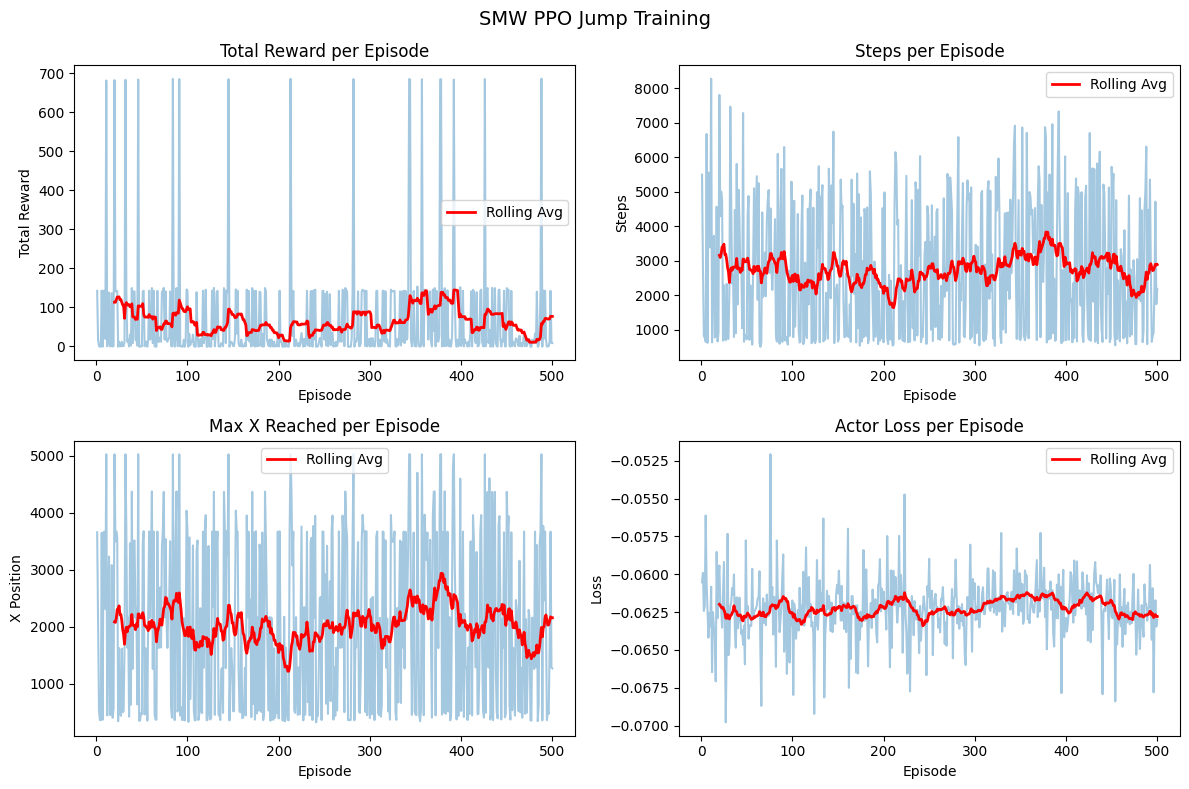

In [46]:
num_eps = len(total_rewards)
eps = range(1, num_eps + 1)
window = 20
rolling_eps = range(window, num_eps + 1)

fig, axes = plt.subplots(2, 2, figsize=(12, 8))
fig.suptitle('SMW PPO Jump Training', fontsize=14)

axes[0, 0].plot(eps, total_rewards, alpha=0.4)
rolling_avg = np.convolve(total_rewards, np.ones(window)/window, mode='valid')
axes[0, 0].plot(rolling_eps, rolling_avg, color='red', linewidth=2, label='Rolling Avg')
axes[0, 0].set_title('Total Reward per Episode')
axes[0, 0].set_xlabel('Episode')
axes[0, 0].set_ylabel('Total Reward')
axes[0, 0].legend()

axes[0, 1].plot(eps, steps_per_ep, alpha=0.4)
rolling_steps = np.convolve(steps_per_ep, np.ones(window)/window, mode='valid')
axes[0, 1].plot(rolling_eps, rolling_steps, color='red', linewidth=2, label='Rolling Avg')
axes[0, 1].set_title('Steps per Episode')
axes[0, 1].set_xlabel('Episode')
axes[0, 1].set_ylabel('Steps')
axes[0, 1].legend()

axes[1, 0].plot(eps, max_x_per_ep, alpha=0.4)
rolling_x = np.convolve(max_x_per_ep, np.ones(window)/window, mode='valid')
axes[1, 0].plot(rolling_eps, rolling_x, color='red', linewidth=2, label='Rolling Avg')
axes[1, 0].set_title('Max X Reached per Episode')
axes[1, 0].set_xlabel('Episode')
axes[1, 0].set_ylabel('X Position')
axes[1, 0].legend()

axes[1, 1].plot(eps, actor_losses, alpha=0.4)
rolling_loss = np.convolve(actor_losses, np.ones(window)/window, mode='valid')
axes[1, 1].plot(rolling_eps, rolling_loss, color='red', linewidth=2, label='Rolling Avg')
axes[1, 1].set_title('Actor Loss per Episode')
axes[1, 1].set_xlabel('Episode')
axes[1, 1].set_ylabel('Loss')
axes[1, 1].legend()

plt.tight_layout()
plt.savefig('Graphs/Jump_03ent_500_results.png')
plt.show()

In [13]:
# test a bunch of addresses around where x should be
import stable_retro

env = stable_retro.make(game='SuperMarioWorld-Snes-v0', render_mode='human')
env.reset()

for _ in range(100):
    action = [0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0]  # hold right
    env.step(action)

ram = env.get_ram()
# print addresses in the range we care about
for addr in [0x00D1, 0x00D3, 0x0086, 0x00D4, 0x00B6, 0x00B8]:
    print(f"0x{addr:04X}: {ram[addr]}")
    print(0x7E0000 + 0x00D1)  # x
    print(0x7E0000 + 0x00D4)  # screen  

env.close()

RuntimeError: Cannot create multiple emulator instances per process, make sure to call env.close() on each environment before creating a new one